# Plotting after QC filter

In [1]:
source(here::here("settings.R"))
source(here::here("load_archr.R"))

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [2]:
io$outdir <- file.path(io$basedir,"ArchR/QualityControl")

In [3]:
metadata_preQC = fread(file.path(io$output.directory, 'metadata.txt.gz'))
metadata_postQC = as.data.table(ArchRProject@cellColData)

In [13]:
QC_plot = metadata_postQC %>% 
    .[,c('Sample', 'TSSEnrichment', 'nFrags', 'FRIP', 'stage', 'cell')] %>%
    melt(id.vars = c('cell','Sample', 'stage'), variable.name='statistic', value.name='value') %>%
    .[,Sample:=gsub('rabbit_', '', Sample)]

In [14]:
table(QC_plot$Sample)


BGRGP1 BGRGP2 BGRGP3 BGRGP4 BGRGP5 BGRGP6 BGRGP7 BGRGP8 
 26250  12246  13008   4887  12192  11982  11313  10368 

In [17]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR"

In [18]:
fwrite(QC_plot, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/Figures_data_NCB/S6B_QC.csv')

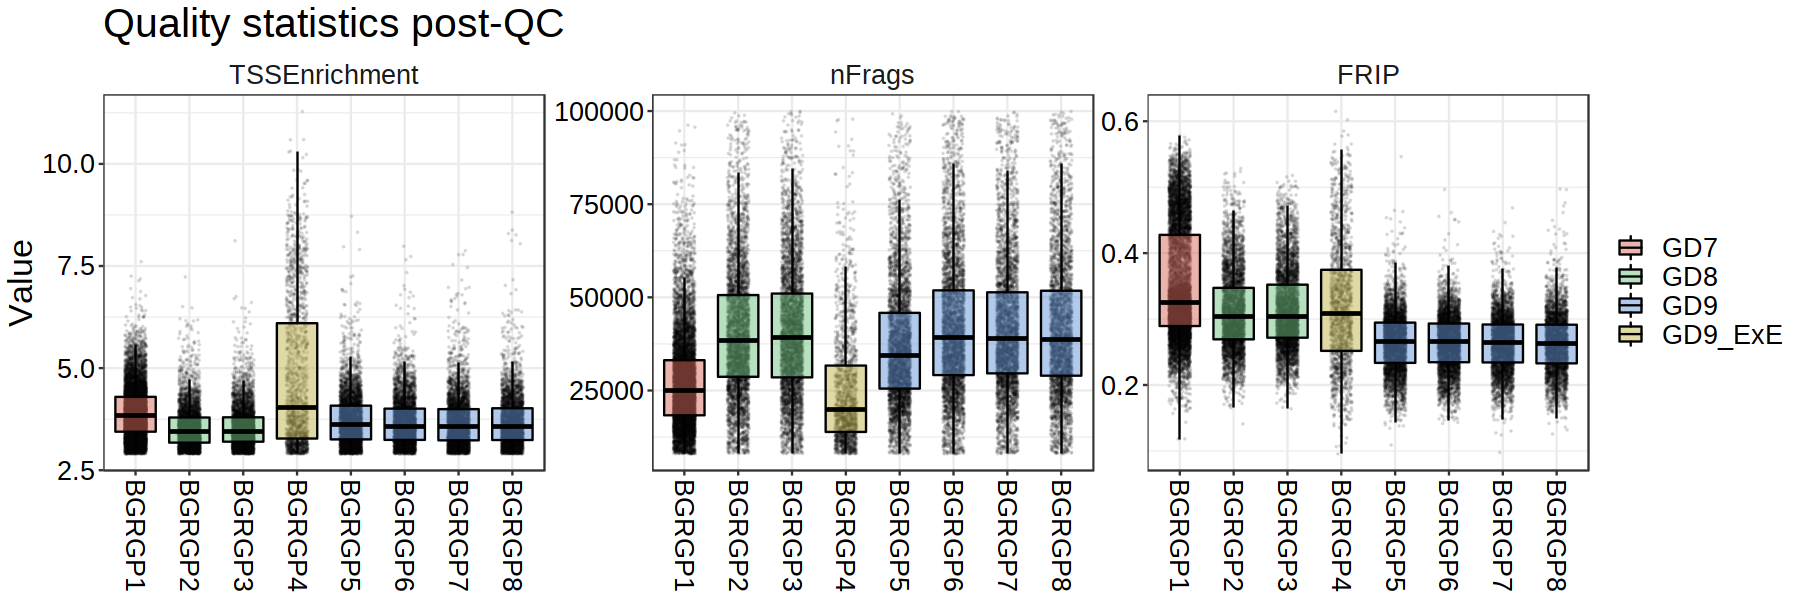

In [9]:
p = ggplot(QC_plot, aes(Sample, value)) + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, aes(fill=stage), col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    facet_wrap(~statistic, scales='free') +
    #ylim(0, NA) + 
    ylab('Value') + 
    ggtitle('Quality statistics post-QC') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(1), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(1)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p 

In [10]:
paste('Median TSSEnrichment: ', median(metadata_postQC$TSSEnrichment))
paste('Median nFrags: ', median(metadata_postQC$nFrags))
paste('Median FRIP: ', round(median(metadata_postQC$FRIP),2))

[1] "Median TSSEnrichment:  3.615"

[1] "Median nFrags:  33602"

[1] "Median FRIP:  0.29"

In [8]:
median(metadata_postQC$PromoterRatio)

[1] 0.08593461

In [9]:
ArchRProject@geneAnnotation$TSS

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

In [28]:
pdf(sprintf("%s/qc_metrics_boxplot_postQC.pdf",io$outdir), width=9, height=3)
    p
dev.off()

png 
  2

In [4]:
addArchRThreads(8)

Setting default number of Parallel threads to 8.



In [5]:
fragment_sizes = plotFragmentSizes(
  ArchRProj = ArchRProject,
  groupBy = "Sample",
  chromSizes = getChromSizes(ArchRProject),
  maxSize = 750,
  returnDF = TRUE)

In [7]:
fragment_sizes = as.data.table(fragment_sizes)
fwrite(fragment_sizes, sprintf('%s/fragment_sizes.txt.gz', io$outdir))

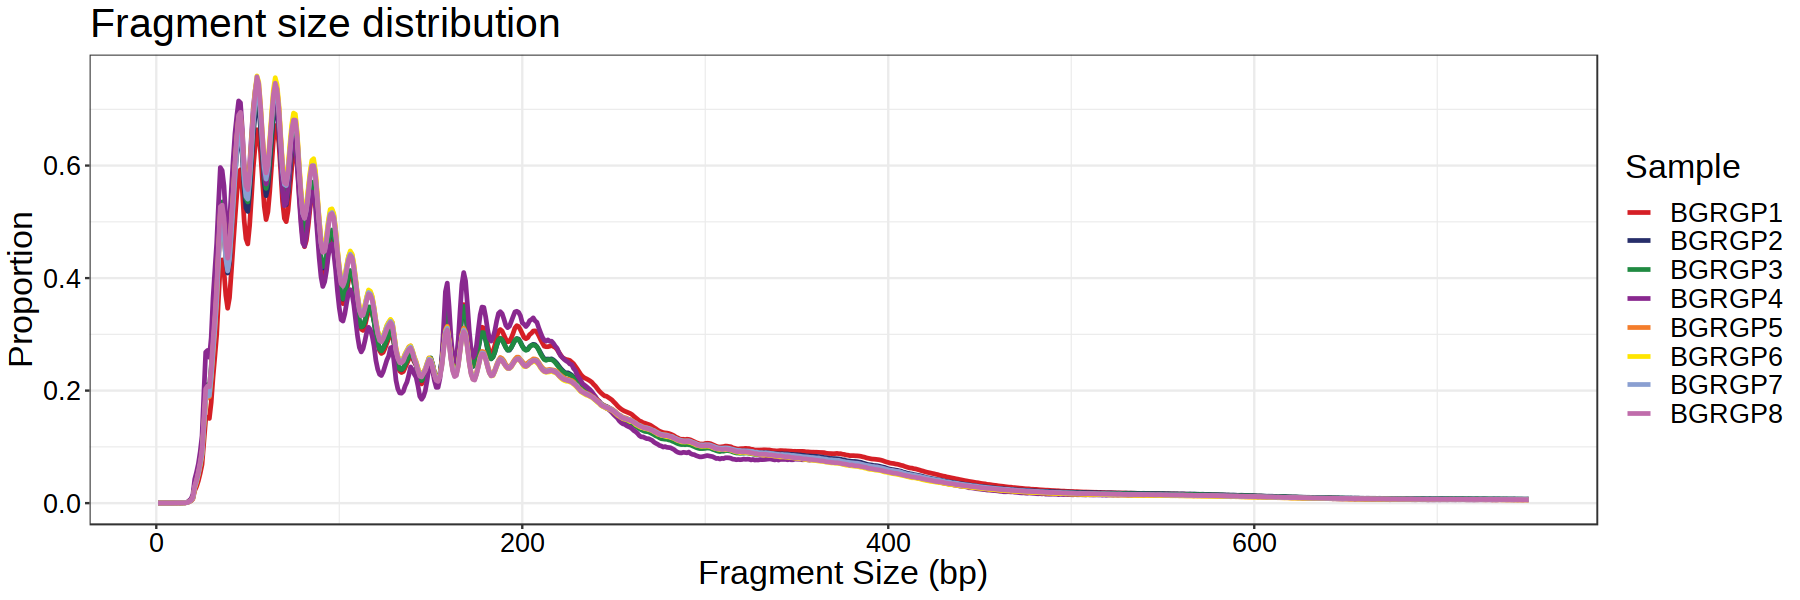

In [36]:
to.plot = as.data.table(fragment_sizes) %>%
    .[, group:=gsub('rabbit_', '', group)]
palette = ArchRPalettes$stallion[1:8]
names(palette) = unique(to.plot$group)

p = ggplot(to.plot, aes(fragmentSize,  fragmentPercent, col=group)) + 
    geom_line(size=1) + 
    scale_color_manual(values = palette, name='Sample') + 
    ylab('Proportion') + 
    xlab('Fragment Size (bp)') + 
    ggtitle('Fragment size distribution') +
    theme_bw() + 
    theme(text=element_text(size=20),
          axis.text=element_text(color='black'))
p 

In [39]:
pdf(sprintf("%s/Fragment_size_distribution.pdf",io$outdir), width=5, height=3)
    p
dev.off()

png 
  2

In [19]:
fragment_sizes = fread(sprintf('%s/fragment_sizes.txt.gz', io$outdir))

In [22]:
fwrite(fragment_sizes, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/Figures_data_NCB/S6C_fragment_sizes.csv')